<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Pop_Pyramid_Clustering/blob/main/pop_pyramids_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#spectral with countries

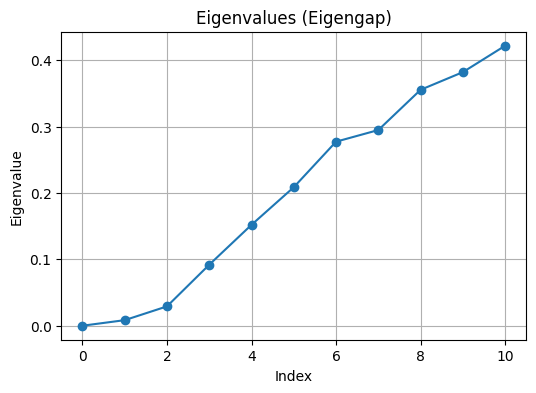

Optimal number of clusters: 6
                        Country  Cluster
5                     Argentina        0
4           Antigua and Barbuda        0
10                      Bahamas        0
9                    Azerbaijan        0
11                      Bahrain        0
22                       Brazil        0
23            Brunei Darussalam        0
18                       Bhutan        0
51                      Ecuador        0
50           Dominican Republic        0
36                     Colombia        0
59                         Fiji        0
39                   Costa Rica        0
125                        Oman        0
114                     Myanmar        0
112                     Morocco        0
98                        Libya        0
103                    Malaysia        0
109                      Mexico        0
104                    Maldives        0
127                      Panama        0
95                      Lebanon        0
91                       Ku

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# PROMPT
# Spectral clustering of countries using population
# pyramids (21 age groups) with kNN affinity
# =====================================================

CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_NEIGHBORS = 12     # VERY IMPORTANT (8–15 works well)
MAX_EIGEN = 11

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()

df_pivot = df_year.pivot(
    index="Location",
    columns="AgeGrp",
    values="PopTotal"
).fillna(0)

countries = df_pivot.index.values
X = df_pivot.values

assert X.shape[1] == 21, "Must have exactly 21 age groups"

# =========================
# NORMALIZE PYRAMIDS
# =========================
X = normalize(X, norm="l1")

# =========================
# BUILD kNN AFFINITY GRAPH
# =========================
W = kneighbors_graph(
    X,
    n_neighbors=N_NEIGHBORS,
    mode="connectivity",
    include_self=False
)

# make symmetric
W = 0.5 * (W + W.T)
W = W.toarray()

# =========================
# NORMALIZED LAPLACIAN
# =========================
degree = np.sum(W, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

# =========================
# EIGENGAP
# =========================
eigenvals, _ = np.linalg.eigh(L)

plt.figure(figsize=(6,4))
plt.plot(eigenvals[:MAX_EIGEN], marker="o")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues (Eigengap)")
plt.grid(True)
plt.show()

gaps = np.diff(eigenvals[:MAX_EIGEN])
optimal_k = np.argmax(gaps) + 1

print("Optimal number of clusters:", optimal_k)

# =========================
# FINAL SPECTRAL CLUSTERING
# =========================
sc = SpectralClustering(
    n_clusters=optimal_k,
    affinity="nearest_neighbors",
    n_neighbors=N_NEIGHBORS,
    assign_labels="kmeans",
    random_state=42
)

labels = sc.fit_predict(X)

# =========================
# OUTPUT
# =========================
results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels
}).sort_values("Cluster")

print(results.head(30))
print("\nCluster sizes:")
print(results["Cluster"].value_counts().sort_index())

print("Cluster 0:", ", ".join(results[results['Cluster'] == 0]['Country'].sort_values()))
print("Cluster 1:", ", ".join(results[results['Cluster'] == 1]['Country'].sort_values()))
print("Cluster 2:", ", ".join(results[results['Cluster'] == 2]['Country'].sort_values()))


Processing years: [np.int64(1975), np.int64(1980), np.int64(1985), np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2025)]

Processing year: 1975
Computed optimal k for 1975: 3 (but using fixed k=3)
Cluster sizes for 1975:
Cluster
0    81
1    61
2    45
Name: count, dtype: int64

Processing year: 1980
Computed optimal k for 1980: 5 (but using fixed k=3)
Cluster sizes for 1980:
Cluster
0    77
1    64
2    46
Name: count, dtype: int64

Processing year: 1985
Computed optimal k for 1985: 7 (but using fixed k=3)
Cluster sizes for 1985:
Cluster
0    72
1    71
2    44
Name: count, dtype: int64

Processing year: 1990
Computed optimal k for 1990: 9 (but using fixed k=3)
Cluster sizes for 1990:
Cluster
0    70
1    69
2    48
Name: count, dtype: int64

Processing year: 1995
Computed optimal k for 1995: 9 (but using fixed k=3)
Cluster sizes for 1995:
Cluster
0    67
1    68
2    52
Name: count, dtype: int64

Processing yea

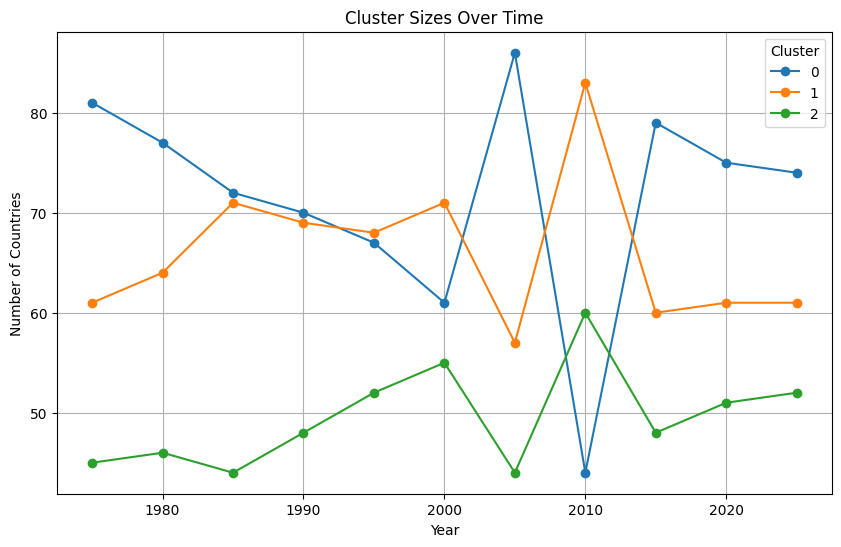

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# PROMPT
# Spectral clustering of countries using population
# pyramids (21 age groups) with kNN affinity
# Over time period 1975-2025
# =====================================================
CSV_PATH = "age_data_1.csv"
START_YEAR = 1975
END_YEAR = 2025
YEAR_STEP = 5  # Use 5-year steps to make it manageable; change to 1 for annual
N_NEIGHBORS = 12  # VERY IMPORTANT (8–15 works well)
MAX_EIGEN = 11
FIXED_K = 3  # Fix to 3 clusters for consistency over time (based on 2020 optimal)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
unique_years = sorted(df['Time'].unique())
years = [y for y in unique_years if START_YEAR <= y <= END_YEAR and (y - START_YEAR) % YEAR_STEP == 0]
print(f"Processing years: {years}")

# Prepare to collect results across years
all_results = []

for YEAR in years:
    print(f"\nProcessing year: {YEAR}")

    df_year = df[df["Time"] == YEAR].copy()
    if df_year.empty:
        print(f"No data for {YEAR}, skipping.")
        continue

    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values
    assert X.shape[1] == 21, "Must have exactly 21 age groups"

    # =========================
    # NORMALIZE PYRAMIDS
    # =========================
    X = normalize(X, norm="l1")

    # =========================
    # BUILD kNN AFFINITY GRAPH
    # =========================
    W = kneighbors_graph(
        X,
        n_neighbors=N_NEIGHBORS,
        mode="connectivity",
        include_self=False
    )
    # make symmetric
    W = 0.5 * (W + W.T)
    W = W.toarray()

    # =========================
    # NORMALIZED LAPLACIAN
    # =========================
    degree = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
    L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

    # =========================
    # EIGENGAP (for info, but we'll use FIXED_K)
    # =========================
    eigenvals, _ = np.linalg.eigh(L)
    gaps = np.diff(eigenvals[:MAX_EIGEN])
    optimal_k = np.argmax(gaps) + 1
    print(f"Computed optimal k for {YEAR}: {optimal_k} (but using fixed k={FIXED_K})")

    # Plot eigengap (optional, comment out if too many plots)
    # plt.figure(figsize=(6,4))
    # plt.plot(eigenvals[:MAX_EIGEN], marker="o")
    # plt.xlabel("Index")
    # plt.ylabel("Eigenvalue")
    # plt.title(f"Eigenvalues (Eigengap) for {YEAR}")
    # plt.grid(True)
    # plt.show()

    # =========================
    # FINAL SPECTRAL CLUSTERING
    # =========================
    sc = SpectralClustering(
        n_clusters=FIXED_K,
        affinity="nearest_neighbors",
        n_neighbors=N_NEIGHBORS,
        assign_labels="kmeans",
        random_state=42
    )
    labels = sc.fit_predict(X)

    # =========================
    # COLLECT RESULTS
    # =========================
    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })
    all_results.append(year_results)

    # Print cluster sizes for this year
    print(f"Cluster sizes for {YEAR}:")
    print(year_results["Cluster"].value_counts().sort_index())

# Combine all results
full_df = pd.concat(all_results, ignore_index=True)

# Save to CSV for further analysis
full_df.to_csv("cluster_results_1975_2025.csv", index=False)
print("\nSaved results to 'cluster_results_1975_2025.csv'")

# Optional: Pivot for country-year-cluster table
pivot_df = full_df.pivot(index="Country", columns="Year", values="Cluster")
pivot_df.to_csv("cluster_pivot_1975_2025.csv")
print("Saved pivot table to 'cluster_pivot_1975_2025.csv'")

# Optional: Visualize cluster sizes over time
cluster_sizes = full_df.groupby(["Year", "Cluster"]).size().unstack(fill_value=0)
cluster_sizes.plot(kind="line", marker="o", figsize=(10,6))
plt.title("Cluster Sizes Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

In [ ]:
#optimal and hyper prameter change


Processing year: 1950
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    103
1     55
2     29
Name: count, dtype: int64

Processing year: 1955
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    58
1    43
2    86
Name: count, dtype: int64

Processing year: 1960
Optimal number of clusters: 4
Cluster sizes:
Cluster
0    43
1    96
2    16
3    32
Name: count, dtype: int64

Processing year: 1965
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    44
1    47
2    96
Name: count, dtype: int64

Processing year: 1970
Optimal number of clusters: 2
Cluster sizes:
Cluster
0    140
1     47
Name: count, dtype: int64

Processing year: 1975
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    81
1    61
2    45
Name: count, dtype: int64

Processing year: 1980
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    77
1    64
2    46
Name: count, dtype: int64

Processing year: 1985
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    72
1    71
2    44
Name: count, 

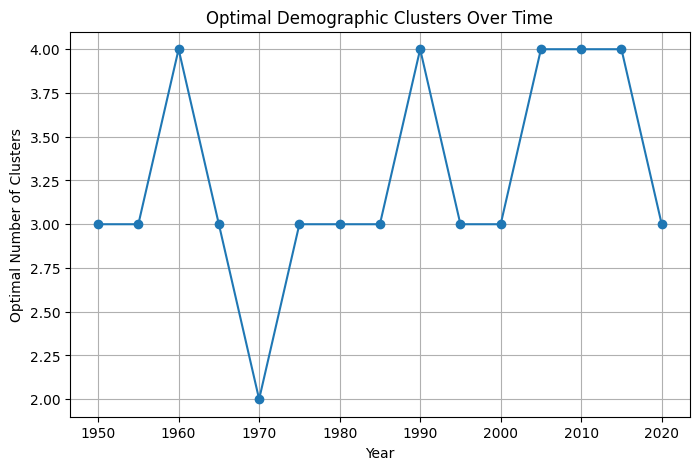

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# Spectral clustering of countries using population
# pyramids (21 age groups)
# Optimal number of clusters per year (1975–2025)
# =====================================================

CSV_PATH = "age_data_1.csv"
START_YEAR = 1950
END_YEAR = 2020
YEAR_STEP = 5

N_NEIGHBORS = 12       # kNN affinity (8–15 recommended)
MAX_EIGEN = 5       # eigenvalues inspected for eigengap
MIN_K = 2
MAX_K = 7             # plausible demographic range

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)

years = sorted(
    y for y in df["Time"].unique()
    if START_YEAR <= y <= END_YEAR and (y - START_YEAR) % YEAR_STEP == 0
)

all_results = []
k_summary = []

# =========================
# LOOP OVER YEARS
# =========================
for YEAR in years:
    print(f"\nProcessing year: {YEAR}")

    df_year = df[df["Time"] == YEAR]
    if df_year.empty:
        print("No data, skipping.")
        continue

    # Country × age-group matrix
    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values

    assert X.shape[1] == 21, "Expected exactly 21 age groups"

    # =========================
    # NORMALIZE PYRAMIDS
    # =========================
    X = normalize(X, norm="l1")

    # =========================
    # kNN AFFINITY GRAPH
    # =========================
    W = kneighbors_graph(
        X,
        n_neighbors=N_NEIGHBORS,
        mode="connectivity",
        include_self=False
    )

    W = 0.5 * (W + W.T)
    W = W.toarray()

    # =========================
    # NORMALIZED LAPLACIAN
    # =========================
    degree = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
    L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

    # =========================
    # EIGENGAP → OPTIMAL K
    # =========================
    eigenvals, _ = np.linalg.eigh(L)

    gaps = np.diff(eigenvals[:MAX_EIGEN])
    raw_k = np.argmax(gaps) + 1
    optimal_k = min(max(raw_k, MIN_K), MAX_K)

    print(f"Optimal number of clusters: {optimal_k}")

    k_summary.append({
        "Year": YEAR,
        "Optimal_K": optimal_k
    })

    # =========================
    # SPECTRAL CLUSTERING
    # =========================
    sc = SpectralClustering(
        n_clusters=optimal_k,
        affinity="nearest_neighbors",
        n_neighbors=N_NEIGHBORS,
        assign_labels="kmeans",
        random_state=42
    )

    labels = sc.fit_predict(X)

    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })

    all_results.append(year_results)

    print("Cluster sizes:")
    print(year_results["Cluster"].value_counts().sort_index())

# =========================
# SAVE RESULTS
# =========================
full_df = pd.concat(all_results, ignore_index=True)
full_df.to_csv("cluster_results_optimalK_1975_2025.csv", index=False)

k_df = pd.DataFrame(k_summary)
k_df.to_csv("optimal_k_by_year.csv", index=False)

print("\nSaved files:")
print("- cluster_results_optimalK_1975_2025.csv")
print("- optimal_k_by_year.csv")

# =========================
# PLOT OPTIMAL K OVER TIME
# =========================
plt.figure(figsize=(8,5))
plt.plot(k_df["Year"], k_df["Optimal_K"], marker="o")
plt.xlabel("Year")
plt.ylabel("Optimal Number of Clusters")
plt.title("Optimal Demographic Clusters Over Time")
plt.grid(True)
plt.show()


#Generating world maps


In [ ]:
# =========================
# WORLD MAPS FOR ALL YEARS (1950 - 2020)
# =========================

import pandas as pd
import plotly.express as px
import os

# Create output folder
os.makedirs("cluster_maps", exist_ok=True)

print("Generating world maps for all years...\n")

# === Choose how to load data ===
# Option 1: If you have all_results list from your loop
if 'all_results' in globals() and len(all_results) > 0:
    df_all = pd.concat(all_results, ignore_index=True)
else:
    # Option 2: Load from saved CSV
    df_all = pd.read_csv("cluster_results_optimalK_1975_2025.csv")

# Denmark → Greenland Fix (applied to all years)
def add_greenland_fix(df):
    if 'Denmark' in df['Country'].values:
        greenland = df[df['Country'] == 'Denmark'].copy()
        greenland['Country'] = 'Greenland'
        return pd.concat([df, greenland], ignore_index=True)
    return df

# Generate map for each year
for YEAR in sorted(df_all['Year'].unique()):
    df_year = df_all[df_all['Year'] == YEAR].copy()
    df_year = add_greenland_fix(df_year)

    # Create nice cluster label
    df_year['Cluster_Label'] = df_year['Cluster'].astype(str)

    fig = px.choropleth(
        df_year,
        locations="Country",
        locationmode="country names",
        color="Cluster_Label",
        hover_name="Country",
        title=f"Global Demographic Clusters {YEAR}",
        color_discrete_sequence=px.colors.qualitative.Set2,
        height=680,
        width=1150
    )

    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        legend_title_text='Cluster',
        margin={"r":0,"t":60,"l":0,"b":0}
    )

    # Save files
    fig.write_html(f"cluster_maps/Global_Demographic_Clusters_{YEAR}.html")
    print(f"Saved interactive map for {YEAR}")

    # Try to save PNG (optional)
    try:
        fig.write_image(f"cluster_maps/Global_Demographic_Clusters_{YEAR}.png", scale=2)
        print(f"   → PNG also saved")
    except:
        pass  # kaleido not installed - HTML is enough

print("\n All maps saved in 'cluster_maps/' folder!")
print("Open the .html files in your browser for best viewing.")

Generating world maps for all years...

Saved interactive map for 1950
Saved interactive map for 1955
Saved interactive map for 1960
Saved interactive map for 1965
Saved interactive map for 1970
Saved interactive map for 1975
Saved interactive map for 1980
Saved interactive map for 1985
Saved interactive map for 1990
Saved interactive map for 1995
Saved interactive map for 2000
Saved interactive map for 2005
Saved interactive map for 2010
Saved interactive map for 2015
Saved interactive map for 2020

 All maps saved in 'cluster_maps/' folder!
Open the .html files in your browser for best viewing.


Try to get world maps

In [ ]:
import pandas as pd
import plotly.express as px
import os
from datetime import datetime

# =========================
# LOAD RESULTS
# =========================
df = pd.read_csv("cluster_results_optimalK_1975_2025.csv")

print(f"Loaded data for {df['Year'].nunique()} years\n")

os.makedirs("cluster_maps", exist_ok=True)
os.makedirs("cluster_summaries", exist_ok=True)

# Denmark/Greenland Fix
def add_greenland_fix(df_year):
    if 'Denmark' in df_year['Country'].values:
        greenland = df_year[df_year['Country'] == 'Denmark'].copy()
        greenland['Country'] = 'Greenland'
        return pd.concat([df_year, greenland], ignore_index=True)
    return df_year

# =========================
# PROCESS EACH YEAR
# =========================
for YEAR in sorted(df['Year'].unique()):
    print(f"\n{'='*60}")
    print(f"Year: {YEAR}")
    print(f"{'='*60}")

    df_year = df[df['Year'] == YEAR].copy()
    df_year = add_greenland_fix(df_year)

    # === COUNTRY LISTS PER CLUSTER ===
    print("Countries by Cluster:")
    summary_text = f"GLOBAL DEMOGRAPHIC CLUSTERS - {YEAR}\n"
    summary_text += "="*50 + "\n\n"

    cluster_countries = {}
    for cl in sorted(df_year['Cluster'].unique()):
        countries = df_year[df_year['Cluster'] == cl]['Country'].sort_values().tolist()
        count = len(countries)
        cluster_countries[cl] = countries

        print(f"\nCluster {cl} ({count} countries):")
        summary_text += f"Cluster {cl} ({count} countries):\n"
        summary_text += "-" * 40 + "\n"

        # Print nicely
        if count > 20:
            print(", ".join(countries[:20]) + f", ... and {count-20} more")
            summary_text += ", ".join(countries) + "\n\n"
        else:
            print(", ".join(countries))
            summary_text += ", ".join(countries) + "\n\n"

    # Save per-year summary
    with open(f"cluster_summaries/countries_by_cluster_{YEAR}.txt", "w", encoding="utf-8") as f:
        f.write(summary_text)

    # === WORLD MAP ===
    df_year['Cluster_Label'] = 'Cluster ' + df_year['Cluster'].astype(str)

    fig = px.choropleth(
        df_year,
        locations="Country",
        locationmode="country names",
        color="Cluster_Label",
        hover_name="Country",
        title=f"Global Demographic Clusters {YEAR} (Spectral Clustering)",
        color_discrete_sequence=px.colors.qualitative.Set2,
        height=700,
        width=1200
    )

    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        legend_title_text='Demographic Cluster',
        margin={"r":0,"t":80,"l":0,"b":0}
    )

    fig.write_html(f"cluster_maps/Global_Demographic_Clusters_{YEAR}.html")
    print(f"✅ Map saved → cluster_maps/Global_Demographic_Clusters_{YEAR}.html")

    # Try to save PNG (optional)
    try:
        fig.write_image(f"cluster_maps/Global_Demographic_Clusters_{YEAR}.png", scale=2)
        print(f"✅ PNG also saved")
    except:
        pass

print("\n🎉 All done!")
print("📁 Check these folders:")
print("   • cluster_maps/          → Interactive world maps")
print("   • cluster_summaries/     → Text files with country lists per cluster")

Loaded data for 15 years


Year: 1950
Countries by Cluster:

Cluster 0 (1 countries):
Guam

Cluster 1 (187 countries):
Afghanistan, Albania, Algeria, Angola, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Benin, Bhutan, Bolivia (Plurinational State of), ... and 167 more
✅ Map saved → cluster_maps/Global_Demographic_Clusters_1950.html

Year: 1955
Countries by Cluster:

Cluster 0 (63 countries):
Algeria, Belize, Bhutan, Botswana, Burundi, Cambodia, China, Taiwan Province of China, Colombia, Costa Rica, Côte d'Ivoire, Democratic Republic of the Congo, Djibouti, Dominican Republic, Ecuador, El Salvador, Eritrea, Eswatini, Ethiopia, Fiji, Gambia, ... and 43 more

Cluster 1 (3 countries):
Guam, Kuwait, Sao Tome and Principe

Cluster 2 (67 countries):
Afghanistan, Albania, Angola, Antigua and Barbuda, Bahamas, Bahrain, Bangladesh, Barbados, Benin, Bolivia (Plurinational State of), Bosnia and Herzegovin


Estimating k for year: 1950
Suggested k from eigengap: 5
Used neighbours: 12
Graph components: 1

Estimating k for year: 1955
Suggested k from eigengap: 7
Used neighbours: 12
Graph components: 1

Estimating k for year: 1960
Suggested k from eigengap: 7
Used neighbours: 12
Graph components: 1

Estimating k for year: 1965
Suggested k from eigengap: 5
Used neighbours: 12
Graph components: 1

Estimating k for year: 1970
Suggested k from eigengap: 6
Used neighbours: 12
Graph components: 1

Estimating k for year: 1975
Suggested k from eigengap: 4
Used neighbours: 12
Graph components: 1

Estimating k for year: 1980
Suggested k from eigengap: 5
Used neighbours: 12
Graph components: 1

Estimating k for year: 1985
Suggested k from eigengap: 6
Used neighbours: 12
Graph components: 1

Estimating k for year: 1990
Suggested k from eigengap: 6
Used neighbours: 12
Graph components: 1

Estimating k for year: 1995
Suggested k from eigengap: 7
Used neighbours: 12
Graph components: 1

Estimating k for ye

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Cluster sizes:
Cluster
0    67
1    68
2     5
3    18
4     5
5    13
6    11
Name: count, dtype: int64

Clustering year: 1980
Final number of clusters used: 7
Cluster sizes:
Cluster
0    69
1    54
2    18
3     4
4     8
5    21
6    13
Name: count, dtype: int64

Clustering year: 1985
Final number of clusters used: 7
Cluster sizes:
Cluster
0    74
1    48
2     2
3    17
4    13
5    19
6    14
Name: count, dtype: int64

Clustering year: 1990
Final number of clusters used: 7
Cluster sizes:
Cluster
0    72
1     3
2    54
3     2
4    24
5    18
6    14
Name: count, dtype: int64

Clustering year: 1995
Final number of clusters used: 7
Cluster sizes:
Cluster
0    84
1     4
2    45
3    22
4     9
5     9
6    14
Name: count, dtype: int64

Clustering year: 2000
Final number of clusters used: 7
Cluster sizes:
Cluster
0    27
1    48
2     5
3    48
4    27
5    17
6    15
Name: count, dtype: int64

Clustering year: 2005
Final number of clusters used: 7
Cluster sizes:
Cluster
0    35
1  

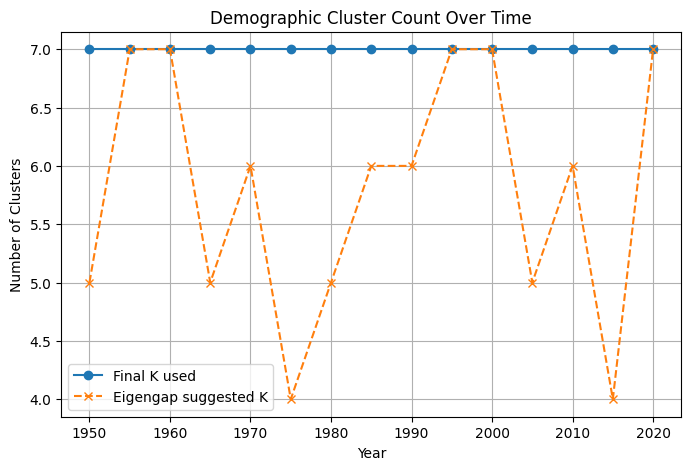

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import connected_components

# =====================================================
# Spectral clustering of countries using population
# pyramids (21 age groups)
# More interpretable stationary clustering over time
# =====================================================

CSV_PATH = "age_data_1.csv"
START_YEAR = 1950
END_YEAR = 2020
YEAR_STEP = 5

N_NEIGHBORS = 12
MIN_K = 2
MAX_K = 7

# Important fix:
# To test k up to MAX_K, we must inspect at least MAX_K + 1 eigenvalues.
MAX_EIGEN = MAX_K + 1

# If True, use one stable k for all years.
# This is recommended for interpretable stationary clustering over time.
USE_GLOBAL_K = True
GLOBAL_K = None

# Kept for downstream compatibility with your existing code
OUTPUT_CLUSTER_CSV = "cluster_results_optimalK_1975_2025.csv"
OUTPUT_K_CSV = "optimal_k_by_year.csv"

# =========================
# HELPER FUNCTIONS
# =========================

def age_midpoint(age_label):
    """
    Converts age group labels such as '0-4', '5-9', '100+' into approximate midpoints.
    Used only to order cluster labels from younger to older.
    """
    s = str(age_label)

    if "+" in s:
        nums = re.findall(r"\d+", s)
        return float(nums[0]) + 2.5 if nums else 100.0

    nums = re.findall(r"\d+", s)
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2.0
    elif len(nums) == 1:
        return float(nums[0])
    else:
        return 0.0


def build_weighted_knn_affinity(X, n_neighbors):
    """
    Builds a symmetric weighted kNN graph.

    This is better than binary connectivity because it preserves how similar
    neighbouring population pyramids are.
    """
    n_samples = X.shape[0]
    n_neighbors = min(n_neighbors, n_samples - 1)

    max_neighbors = min(max(30, n_neighbors), n_samples - 1)

    last_W = None
    last_used_neighbors = n_neighbors
    last_n_components = None
    last_sigma = None

    for used_neighbors in range(n_neighbors, max_neighbors + 1):

        # Use cosine distance because X is a distribution over age groups.
        A = kneighbors_graph(
            X,
            n_neighbors=used_neighbors,
            mode="distance",
            metric="cosine",
            include_self=False
        )

        # Symmetric union of directed kNN edges
        A = A.maximum(A.T).tocsr()

        distances = A.data
        positive_distances = distances[distances > 1e-12]

        if len(positive_distances) == 0:
            sigma = 1.0
        else:
            sigma = np.median(positive_distances)

        W_sparse = A.copy()
        W_sparse.data = np.exp(-(W_sparse.data ** 2) / (2.0 * sigma ** 2))

        W_sparse.setdiag(0)
        W_sparse.eliminate_zeros()

        n_components, _ = connected_components(
            (W_sparse > 0).astype(int),
            directed=False
        )

        last_W = W_sparse.toarray()
        last_used_neighbors = used_neighbors
        last_n_components = n_components
        last_sigma = sigma

        # Prefer a connected graph for stable eigengap estimation.
        if n_components == 1:
            break

    return last_W, last_used_neighbors, last_n_components, last_sigma


def normalized_laplacian(W):
    degree = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
    L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt
    return L


def estimate_k_from_eigengap(eigenvals):
    """
    For k clusters, inspect the gap lambda_{k+1} - lambda_k.
    In zero-based indexing, this is eigenvals[k] - eigenvals[k-1].
    """
    max_valid_k = min(MAX_K, len(eigenvals) - 1)
    candidate_ks = np.arange(MIN_K, max_valid_k + 1)

    gaps = np.array([
        eigenvals[k] - eigenvals[k - 1]
        for k in candidate_ks
    ])

    best_idx = np.argmax(gaps)
    suggested_k = int(candidate_ks[best_idx])

    gap_table = pd.DataFrame({
        "K": candidate_ks,
        "Eigengap": gaps
    })

    return suggested_k, gap_table


def relabel_clusters_by_mean_age(labels, X, age_weights):
    """
    Relabel clusters so that cluster 0 is the youngest age structure
    and higher labels are progressively older.

    This avoids arbitrary label switching between years.
    """
    unique_labels = np.unique(labels)

    cluster_scores = []
    for lab in unique_labels:
        centroid = X[labels == lab].mean(axis=0)
        mean_age = float(np.dot(centroid, age_weights))
        cluster_scores.append((lab, mean_age))

    cluster_scores = sorted(cluster_scores, key=lambda x: x[1])

    label_map = {
        old_label: new_label
        for new_label, (old_label, _) in enumerate(cluster_scores)
    }

    new_labels = np.array([label_map[lab] for lab in labels])

    return new_labels


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)

years = sorted(
    y for y in df["Time"].unique()
    if START_YEAR <= y <= END_YEAR and (y - START_YEAR) % YEAR_STEP == 0
)

all_results = []
k_summary = []
year_cache = []
eigengap_details = []

# =========================
# FIRST PASS: ESTIMATE K PER YEAR
# =========================
for YEAR in years:
    print(f"\nEstimating k for year: {YEAR}")

    df_year = df[df["Time"] == YEAR]
    if df_year.empty:
        print("No data, skipping.")
        continue

    # Ensure age groups are in demographic order, not lexicographic order.
    age_cols = sorted(df_year["AgeGrp"].unique(), key=age_midpoint)

    df_pivot = df_year.pivot_table(
        index="Location",
        columns="AgeGrp",
        values="PopTotal",
        aggfunc="sum"
    ).reindex(columns=age_cols).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values

    assert X.shape[1] == 21, "Expected exactly 21 age groups"

    # Normalize each country's population pyramid to proportions
    X = normalize(X, norm="l1", axis=1)

    age_weights = np.array([age_midpoint(c) for c in age_cols], dtype=float)

    # Weighted kNN affinity graph
    W, used_neighbors, n_components, sigma = build_weighted_knn_affinity(
        X,
        N_NEIGHBORS
    )

    # Normalized Laplacian
    L = normalized_laplacian(W)

    # Eigenvalues
    eigenvals = np.linalg.eigvalsh(L)

    # Eigengap based suggested k
    suggested_k, gap_table = estimate_k_from_eigengap(eigenvals)

    largest_gap = gap_table.loc[
        gap_table["K"] == suggested_k,
        "Eigengap"
    ].iloc[0]

    print(f"Suggested k from eigengap: {suggested_k}")
    print(f"Used neighbours: {used_neighbors}")
    print(f"Graph components: {n_components}")

    gap_table["Year"] = YEAR
    eigengap_details.append(gap_table)

    year_cache.append({
        "Year": YEAR,
        "Countries": countries,
        "X": X,
        "W": W,
        "AgeWeights": age_weights,
        "Suggested_K": suggested_k,
        "Used_Neighbors": used_neighbors,
        "Graph_Components": n_components,
        "Sigma": sigma,
        "Largest_Eigengap": largest_gap
    })

# =========================
# CHOOSE GLOBAL K
# =========================
if USE_GLOBAL_K:
    if GLOBAL_K is None:
        suggested_ks = [item["Suggested_K"] for item in year_cache]

        counts = pd.Series(suggested_ks).value_counts()
        top_count = counts.max()
        top_ks = sorted(counts[counts == top_count].index.tolist())

        # If there is a tie, take the middle value.
        GLOBAL_K = int(round(np.median(top_ks)))

    print(f"\nUsing one global k for all years: {GLOBAL_K}")
else:
    print("\nUsing year-specific suggested k values.")

# =========================
# SECOND PASS: FINAL CLUSTERING
# =========================
for item in year_cache:
    YEAR = item["Year"]
    countries = item["Countries"]
    X = item["X"]
    W = item["W"]
    age_weights = item["AgeWeights"]

    if USE_GLOBAL_K:
        optimal_k = GLOBAL_K
    else:
        optimal_k = item["Suggested_K"]

    print(f"\nClustering year: {YEAR}")
    print(f"Final number of clusters used: {optimal_k}")

    sc = SpectralClustering(
        n_clusters=optimal_k,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42
    )

    labels = sc.fit_predict(W)

    # Relabel clusters from younger to older for interpretability
    labels = relabel_clusters_by_mean_age(labels, X, age_weights)

    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })

    all_results.append(year_results)

    k_summary.append({
        "Year": YEAR,
        "Optimal_K": optimal_k,
        "Suggested_K": item["Suggested_K"],
        "Used_Neighbors": item["Used_Neighbors"],
        "Graph_Components": item["Graph_Components"],
        "Sigma": item["Sigma"],
        "Largest_Eigengap": item["Largest_Eigengap"]
    })

    print("Cluster sizes:")
    print(year_results["Cluster"].value_counts().sort_index())

# =========================
# SAVE RESULTS
# =========================
full_df = pd.concat(all_results, ignore_index=True)
full_df.to_csv(OUTPUT_CLUSTER_CSV, index=False)

k_df = pd.DataFrame(k_summary)
k_df.to_csv(OUTPUT_K_CSV, index=False)

eigengap_df = pd.concat(eigengap_details, ignore_index=True)
eigengap_df.to_csv("eigengap_details_by_year.csv", index=False)

print("\nSaved files:")
print(f"- {OUTPUT_CLUSTER_CSV}")
print(f"- {OUTPUT_K_CSV}")
print("- eigengap_details_by_year.csv")

# =========================
# PLOT K OVER TIME
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    k_df["Year"],
    k_df["Optimal_K"],
    marker="o",
    label="Final K used"
)

plt.plot(
    k_df["Year"],
    k_df["Suggested_K"],
    marker="x",
    linestyle="--",
    label="Eigengap suggested K"
)

plt.xlabel("Year")
plt.ylabel("Number of Clusters")
plt.title("Demographic Cluster Count Over Time")
plt.grid(True)
plt.legend()
plt.show()

PCA - with countries spectral

PCA explained variance (2 components): 0.932


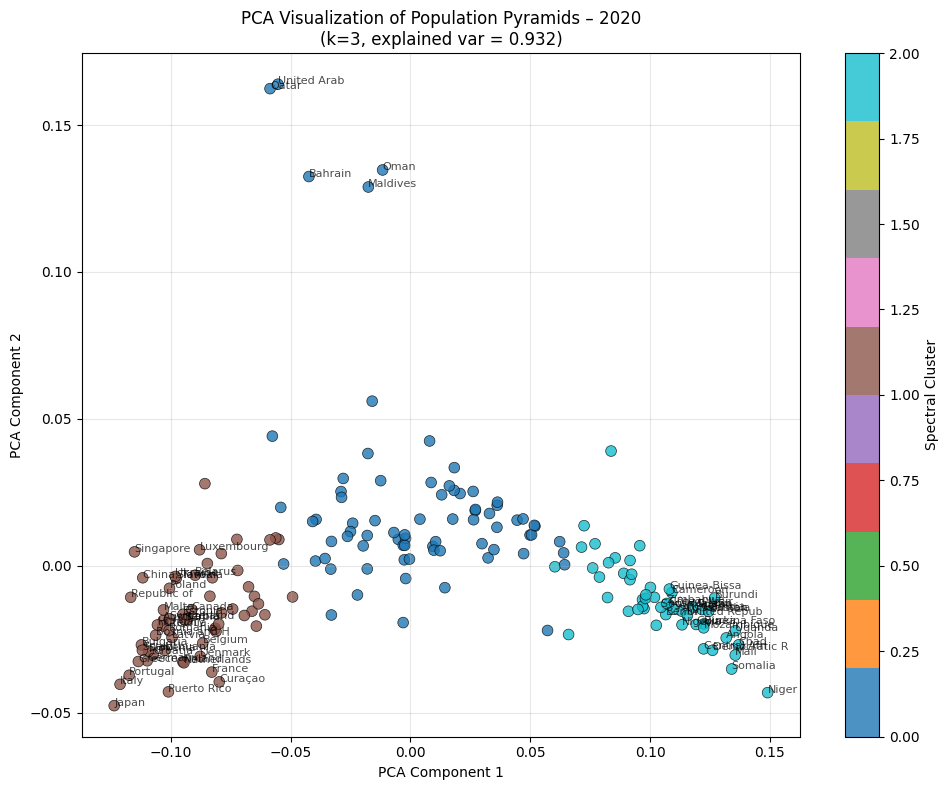


Cluster 0 (75 countries):
Algeria, Antigua and Barbuda, Argentina, Azerbaijan, Bahamas, Bahrain, Bangladesh, Belize, Bhutan, Bolivia (Plurinational State of), Botswana, Brazil, Brunei Darussalam, Cabo Verde, Cambodia ...

Cluster 1 (61 countries):
Albania, Armenia, Australia, Austria, Barbados, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, Chile, China, China, Taiwan Province of China, Croatia, Cuba ...

Cluster 2 (51 countries):
Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Côte d'Ivoire, Democratic Republic of the Congo, Equatorial Guinea, Eritrea, Eswatini ...


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA

# =====================================================
CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_NEIGHBORS = 12
FIXED_K = 3

# Load & prepare
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()
df_pivot = df_year.pivot(index="Location", columns="AgeGrp", values="PopTotal").fillna(0)
countries = df_pivot.index.values
X = df_pivot.values
assert X.shape[1] == 21

# Normalize (L1 = proportions)
X_norm = normalize(X, norm="l1")

# Spectral clustering
W = kneighbors_graph(X_norm, n_neighbors=N_NEIGHBORS, mode="connectivity", include_self=False)
W = 0.5 * (W + W.T)
W = W.toarray()

degree = np.sum(W, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

sc = SpectralClustering(
    n_clusters=FIXED_K,
    affinity="nearest_neighbors",
    n_neighbors=N_NEIGHBORS,
    assign_labels="kmeans",
    random_state=42
)
labels = sc.fit_predict(X_norm)

# -----------------------------
# PCA for visualization (2D)
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA explained variance (2 components): {explained_var:.3f}")

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap="tab10", s=60, alpha=0.8, edgecolor="k", linewidth=0.5
)

# Add country labels for interesting/outlier points (optional)
for i, country in enumerate(countries):
    if (X_pca[i, 0] > X_pca[:,0].max()*0.7 or X_pca[i, 1] > X_pca[:,1].max()*0.7 or
        X_pca[i, 0] < X_pca[:,0].min()*0.7 or X_pca[i, 1] < X_pca[:,1].min()*0.7):
        plt.annotate(country[:12], (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.7)

plt.colorbar(scatter, label="Spectral Cluster")
plt.title(f"PCA Visualization of Population Pyramids – {YEAR}\n"
          f"(k={FIXED_K}, explained var = {explained_var:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print cluster → countries again
results = pd.DataFrame({"Country": countries, "Cluster": labels})
for cl in range(FIXED_K):
    cnts = results[results["Cluster"] == cl]["Country"].sort_values().tolist()
    print(f"\nCluster {cl} ({len(cnts)} countries):")
    print(", ".join(cnts[:15]) + " ..." if len(cnts) > 15 else ", ".join(cnts))

#World map for spectralclustering 2020

In [ ]:
# =========================
# SAVE COUNTRIES PER CLUSTER (Clean & Organized)
# =========================

results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels
})

print("=== COUNTRIES BY CLUSTER (2020) ===\n")

# Create a nice summary file
with open("countries_by_cluster_2020.txt", "w", encoding="utf-8") as f:
    f.write("GLOBAL DEMOGRAPHIC CLUSTERS - 2020\n")
    f.write("="*50 + "\n\n")

    for cl in range(FIXED_K):
        cluster_countries = results[results["Cluster"] == cl]["Country"].sort_values().tolist()
        count = len(cluster_countries)

        print(f"\nCluster {cl} ({count} countries):")
        f.write(f"Cluster {cl} ({count} countries):\n")
        f.write("-" * 40 + "\n")

        # Print first 15 + "..." if more
        if count > 15:
            print(", ".join(cluster_countries[:15]) + f", ... and {count-15} more")
            f.write(", ".join(cluster_countries) + "\n\n")
        else:
            print(", ".join(cluster_countries))
            f.write(", ".join(cluster_countries) + "\n\n")

# Also save full results as CSV
results.to_csv("cluster_results_2020_full.csv", index=False)
print("\n✅ Files saved:")
print("   • countries_by_cluster_2020.txt     (readable summary)")
print("   • cluster_results_2020_full.csv     (full data)")

# Optional: Show top countries per cluster
print("\nQuick View:")
for cl in range(FIXED_K):
    top = results[results["Cluster"] == cl]["Country"].sort_values().head(12).tolist()
    print(f"Cluster {cl}: {', '.join(top)} ...")

=== COUNTRIES BY CLUSTER (2020) ===


Cluster 0 (75 countries):
Algeria, Antigua and Barbuda, Argentina, Azerbaijan, Bahamas, Bahrain, Bangladesh, Belize, Bhutan, Bolivia (Plurinational State of), Botswana, Brazil, Brunei Darussalam, Cabo Verde, Cambodia, ... and 60 more

Cluster 1 (61 countries):
Albania, Armenia, Australia, Austria, Barbados, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, Chile, China, China, Taiwan Province of China, Croatia, Cuba, ... and 46 more

Cluster 2 (51 countries):
Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Côte d'Ivoire, Democratic Republic of the Congo, Equatorial Guinea, Eritrea, Eswatini, ... and 36 more

✅ Files saved:
   • countries_by_cluster_2020.txt     (readable summary)
   • cluster_results_2020_full.csv     (full data)

Quick View:
Cluster 0: Algeria, Antigua and Barbuda, Argentina, Azerbaijan, Bahamas, Bahrain, Bangladesh, Belize, Bhutan, Bolivia (Plurinational State

In [ ]:
# =========================
# GLOBAL DEMOGRAPHIC CLUSTERS WORLD MAP 2020
# =========================

import pandas as pd
import plotly.express as px
import os

os.makedirs("cluster_maps", exist_ok=True)

# === YOUR EXACT CLUSTER COUNTRIES ===
cluster_data = {
    0: ["Algeria", "Antigua and Barbuda", "Argentina", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Belize",
        "Bhutan", "Bolivia (Plurinational State of)", "Botswana", "Brazil", "Brunei Darussalam", "Cabo Verde",
        "Cambodia", "Colombia", "Costa Rica", "Dem. People's Republic of Korea", "Djibouti", "Dominican Republic",
        "Ecuador", "Egypt", "El Salvador", "Fiji", "Grenada", "Guam", "Guatemala", "Guyana", "Haiti", "Honduras",
        "India", "Indonesia", "Iran (Islamic Republic of)", "Israel", "Jamaica", "Jordan", "Kazakhstan", "Kuwait",
        "Kyrgyzstan", "Lao People's Democratic Republic", "Lebanon", "Lesotho", "Libya", "Malaysia", "Maldives",
        "Mexico", "Mongolia", "Morocco", "Myanmar", "Nepal", "Nicaragua", "Oman", "Pakistan", "Panama",
        "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Qatar", "Saint Lucia", "Saint Vincent and the Grenadines",
        "Saudi Arabia", "Seychelles", "South Africa", "Sri Lanka", "Suriname", "Syrian Arab Republic", "Tonga",
        "Tunisia", "Turkey", "Turkmenistan", "United Arab Emirates", "Uzbekistan", "Venezuela (Bolivarian Republic of)",
        "Viet Nam"],

    1: ["Albania", "Armenia", "Australia", "Austria", "Barbados", "Belarus", "Belgium", "Bosnia and Herzegovina",
        "Bulgaria", "Canada", "Chile", "China", "China, Taiwan Province of China", "Croatia", "Cuba", "Curaçao",
        "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", "France", "Georgia", "Germany", "Greece", "Hungary",
        "Iceland", "Ireland", "Israel", "Italy", "Japan", "Latvia", "Lithuania", "Luxembourg", "Malta", "Mauritius",
        "Montenegro", "Netherlands", "New Zealand", "North Macedonia", "Northern Europe", "Norway", "Poland",
        "Portugal", "Puerto Rico", "Republic of Korea", "Republic of Moldova", "Romania", "Russian Federation",
        "Serbia", "Singapore", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Thailand",
        "Trinidad and Tobago", "Ukraine", "United Kingdom", "United States of America", "Uruguay"],

    2: ["Afghanistan", "Angola", "Benin", "Burkina Faso", "Burundi", "Cameroon", "Central African Republic",
        "Chad", "Comoros", "Congo", "Côte d'Ivoire", "Democratic Republic of the Congo", "Equatorial Guinea",
        "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia", "Ghana", "Guinea", "Guinea-Bissau", "Iraq", "Kenya",
        "Kiribati", "Liberia", "Madagascar", "Malawi", "Mali", "Mauritania", "Mozambique", "Namibia", "Niger",
        "Nigeria", "Rwanda", "Samoa", "Sao Tome and Principe", "Senegal", "Sierra Leone", "Solomon Islands",
        "Somalia", "South Sudan", "Sudan", "Tajikistan", "Timor-Leste", "Togo", "Uganda", "United Republic of Tanzania",
        "Vanuatu", "Yemen", "Zambia", "Zimbabwe"]
}

# Create DataFrame
rows = []
for cluster_id, countries in cluster_data.items():
    for country in countries:
        rows.append({'Country': country, 'Cluster': cluster_id})

map_df = pd.DataFrame(rows)

# Denmark → Greenland Fix
if 'Denmark' in map_df['Country'].values:
    greenland = map_df[map_df['Country'] == 'Denmark'].copy()
    greenland['Country'] = 'Greenland'
    map_df = pd.concat([map_df, greenland], ignore_index=True)

# Cluster Labels for Legend
cluster_labels = {
    0: "Cluster 0 - Young / Developing (75 countries)",
    1: "Cluster 1 - Transitional / Developed (61 countries)",
    2: "Cluster 2 - Very Young / High Fertility (51 countries)"
}
map_df['Demographic Stage'] = map_df['Cluster'].map(cluster_labels)

# Create the World Map
fig = px.choropleth(
    map_df,
    locations="Country",
    locationmode="country names",
    color="Demographic Stage",
    hover_name="Country",
    title="Global Demographic Clusters 2020",
    color_discrete_sequence=px.colors.qualitative.Set2,
    height=680,
    width=1150
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    legend_title_text='Demographic Cluster',
    margin={"r":0,"t":60,"l":0,"b":0}
)

fig.show()

# Save
fig.write_html("cluster_maps/Global_Demographic_Clusters_2020.html")
print(" Interactive World Map saved successfully!")

try:
    fig.write_image("cluster_maps/Global_Demographic_Clusters_2020.png", scale=2)
    print(" PNG image also saved!")
except:
    print("Note: For PNG install kaleido (`pip install kaleido`)")

 Interactive World Map saved successfully!
Note: For PNG install kaleido (`pip install kaleido`)


#Spectral clustering - PCA

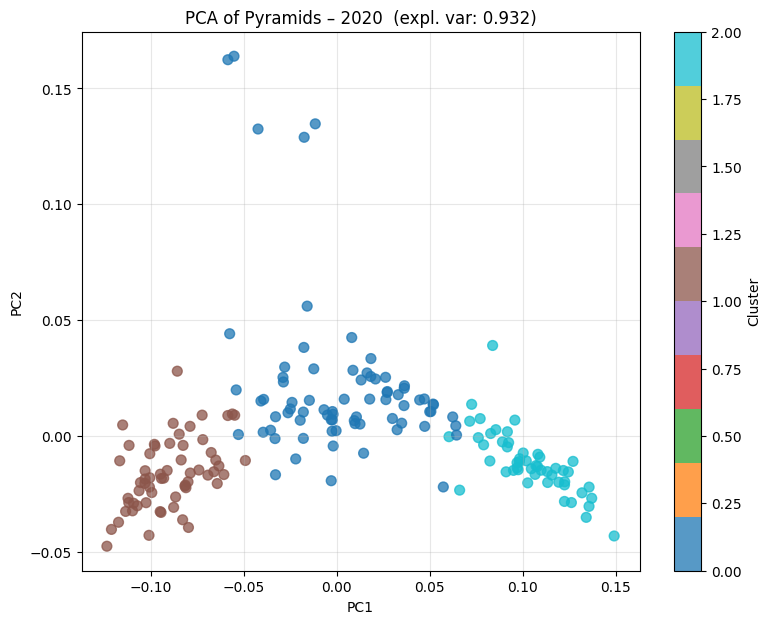

In [ ]:
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_norm)
    explained = pca.explained_variance_ratio_.sum()

    plt.figure(figsize=(9,7))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=50, alpha=0.75)
    plt.title(f"PCA of Pyramids – {YEAR}  (expl. var: {explained:.3f})")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(label="Cluster")
    plt.grid(alpha=0.3)
    plt.savefig(f"pca_pyramids_{YEAR}.png", dpi=150, bbox_inches="tight")
    plt.show()   # or plt.show() if you want interactive


# Spectral clustering - 1950-2100 graphs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# Spectral clustering on population pyramids 1950–2100
# Automatic optimal k via eigengap for EACH year
# =====================================================

CSV_PATH = "age_data_1.csv"          # ← change to your actual file path
N_NEIGHBORS = 15                     # 8–15 usually good; tune if needed
MAX_EIGEN = 15                       # Look at first 15 eigenvalues for gap
MIN_COUNTRIES_PER_YEAR = 100         # Skip years with too few countries

# Load full dataset (can be large — 200+ countries × many years × 21 ages)
df = pd.read_csv(CSV_PATH)

# Get available years in range
years = sorted(df['Time'].unique())
years = [y for y in years if 1950 <= y <= 2100]

print(f"Found {len(years)} years between 1950 and 2100: {years[:5]} ... {years[-5:]}")

optimal_ks = {}
cluster_sizes_per_year = {}
country_cluster_dfs = []   # optional: store full assignments if needed

for YEAR in years:
    print(f"\n{'='*50}\nYear: {YEAR}")

    df_year = df[df["Time"] == YEAR].copy()
    if df_year.empty:
        print(" → No data")
        continue

    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values

    if X.shape[1] != 21:
        print(f" → Skipping: {X.shape[1]} age groups (expected 21)")
        continue

    if len(countries) < MIN_COUNTRIES_PER_YEAR:
        print(f" → Skipping: only {len(countries)} countries")
        continue

    # Normalize rows → proportions (very important!)
    X_norm = normalize(X, norm="l1")

    # Build symmetric kNN graph
    W = kneighbors_graph(
        X_norm,
        n_neighbors=N_NEIGHBORS,
        mode="connectivity",
        include_self=False
    )
    W = 0.5 * (W + W.T)          # symmetrize
    W = W.toarray()

    # Normalized Laplacian
    degree = np.sum(W, axis=1)
    degree[degree == 0] = 1e-10  # avoid div by zero
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))
    L = np.eye(len(countries)) - D_inv_sqrt @ W @ D_inv_sqrt

    # Eigen decomposition (smallest eigenvalues first)
    eigenvals = np.linalg.eigvalsh(L)
    eigenvals = np.sort(eigenvals)[:MAX_EIGEN]

    # Plot eigengap (optional — comment out for speed)
    plt.figure(figsize=(7, 4))
    plt.plot(eigenvals, 'o-', markersize=8)
    plt.title(f"Eigenvalues – {YEAR} ({len(countries)} countries)")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(f"eigengap_{YEAR}.png", dpi=120)
    # plt.close()
    plt.show()   # ← comment if running many years

    # Eigengap heuristic
    gaps = np.diff(eigenvals)
    optimal_k = np.argmax(gaps) + 1
    optimal_ks[YEAR] = optimal_k

    print(f"  Eigenvalues[:{MAX_EIGEN}]: {np.round(eigenvals, 4)}")
    print(f"  Gaps: {np.round(gaps, 4)}")
    print(f"  → Optimal number of clusters (eigengap): **{optimal_k}**")

    # Optional: actually run clustering with this k and save sizes
    if optimal_k >= 2:
        sc = SpectralClustering(
            n_clusters=optimal_k,
            affinity="nearest_neighbors",
            n_neighbors=N_NEIGHBORS,
            assign_labels="kmeans",
            random_state=42
        )
        labels = sc.fit_predict(X_norm)

        sizes = pd.Series(labels).value_counts().sort_index()
        cluster_sizes_per_year[YEAR] = sizes.to_dict()

        print("  Cluster sizes:", sizes.values)

        # Optional: save full assignments
        df_res = pd.DataFrame({"Country": countries, "Cluster": labels, "Year": YEAR})
        country_cluster_dfs.append(df_res)

# Summary table of optimal k over time
k_df = pd.DataFrame.from_dict(optimal_ks, orient='index', columns=['Optimal_k'])
k_df.index.name = 'Year'
print("\nOptimal number of clusters per year (eigengap heuristic):")
print(k_df)

# Plot evolution of optimal k
plt.figure(figsize=(10, 5))
plt.plot(k_df.index, k_df['Optimal_k'], 'o-', linewidth=2, markersize=8)
plt.title("Optimal number of clusters (eigengap) over time 1950–2100")
plt.xlabel("Year")
plt.ylabel("Optimal k")
plt.grid(True)
plt.yticks(range(1, k_df['Optimal_k'].max()+2))
plt.tight_layout()
plt.show()

# Optional: save full results
if country_cluster_dfs:
    pd.concat(country_cluster_dfs).to_csv("spectral_clusters_1950_2100.csv", index=False)
    print("\nSaved full country-cluster assignments → spectral_clusters_1950_2100.csv")

In [ ]:
pip install pycountry